# EDA - Análisis Exploratorio de Datos: Factores de Riesgo de Obesidad

Este notebook sigue un flujo de trabajo estructurado para el análisis exploratorio (EDA).

## Busines Understanding 

La obesidad es una condición de salud global crítica, estrechamente vinculada a enfermedades cardiovasculares, diabetes y affecciones metabólicas. En el entorno clínico y de salud pública, identificar de manera temprana los factores de riesgo que llevan a una persona a desarrollar diferentes grados de obesidad es fundamental para diseñar polítcas de prevención, tratamientos personalizados y optimizar recursos médicos.

** Obejetivo del proyecto **
El objetivo de este proyecto es analizar un conjunto de datos basado en los hábitos de estilo de vida, historial genético y condición física de individuos de México, Perú y Colombia, para construir posteriormente un modelo de machine Learning capaz de predecir el nivel de obesidad de un paciente.

A través de este EDA, se busca responder a preguntas clave: 

1. ¿Es la genética (historial familiar) una sentencia definitiva para la obesidad severa?
2. ¿Qué impacto real `real`tienen los hábitos diarios (consumo de agua, actividad física, horas de pantalla) en el peso?
3. ¿Existen sesgos o desequilibrios en nuestros datos que debamos corregir antes de entrenar un algoritmo predictivos?

--

## 📖 Diccionario de Variables

Para comprender correctamente el conjunto de datos, a continuación se detalla el significado de cada variable registrada:

**Variables Físicas y Biométricas:**
* `gender`: Género del paciente (Femenino / Masculino).
* `age`: Edad en años.
* `height`: Altura en metros.
* `weight`: Peso en kilogramos.

**Variables de Historial y Hábitos Alimenticios:**
* `family_history_with_overweight`: ¿Tiene un familiar con sobrepeso? (yes / no).
* `favc`: Consumo frecuente de alimentos altos en calorías (yes / no).
* `fcvc`: Frecuencia de consumo de vegetales (Escala del 1 al 3).
* `ncp`: Número de comidas principales al día (Escala del 1 al 4).
* `caec`: Consumo de alimentos entre comidas (no / Sometimes / Frequently / Always).
* `ch2o`: Consumo diario de agua en litros (Escala del 1 al 3).
* `calc`: Consumo de alcohol (no / Sometimes / Frequently / Always).

**Variables de Estilo de Vida:**
* `smoke`: ¿Es fumador? (yes / no).
* `scc`: ¿Monitorea las calorías que consume diariamente? (yes / no).
* `faf`: Frecuencia de actividad física semanal (Escala del 0 al 3).
* `tue`: Tiempo dedicado al uso de dispositivos tecnológicos (pantallas) al día (Escala del 0 al 2).
* `mtrans`: Medio de transporte principal utilizado (Automobile, Motorbike, Bike, Public_Transportation, Walking).

**Variable Objetivo (Target):**
* `nobeyesdad`: Clasificación médica del nivel de peso (Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III).

Importamos librerías estándar de la industria: `pandas` y `numpy` para manipulación de datos, `matplotlib` y `seaborn` para visualización. Usamos `%matplotlib inline` para que los gráficos se vean directamente en el notebook y `sns.set_theme` asegura un estilo limpio y uniforme en todas las gráficas.

In [89]:
# Importamos las librerías estándar de la industria
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# %matplotlib inline asegura que los gráficos se rendericen dentro del notebook
%matplotlib inline

# Configuración estética profesional
sns.set_theme(style="whitegrid", context="notebook")

## 1. Carga de Datos y Estandarización

En esta primera etapa, aplicaremos las mejores prácticas de ingeniería de datos realizando una limpieza avanzada de las columnas: las pasaremos a formato `snake_case`(minúsculas y guiones bajos) para evitar errores tipográficos y de compatibilidad en futuros entornos de producción.

In [90]:
np.random.seed(42) 

# Cargar dataset original y copiarlo
df_raw = pd.read_csv('../data/raw/ObesityDataSet.csv')
df = df_raw.copy()

# Limpieza avanzada de nombres de columnas
df.columns = (
    df.columns
    .str.strip()             # Quita espacios al inicio/final
    .str.lower()             # Convierte a minúsculas
    .str.replace(' ', '_')   # Reemplaza espacios internos por guiones bajos
    .str.replace(r'[^\w]', '', regex=True)  # Elimina caracteres especiales
)

df.head(10)

# Comprobación de los nuevos nombres de columnas (Ejemplo: "NObeyesdad" → "nobeyesdad")
print("Columnas estandarizadas:\n", df.columns.tolist()) # .tolist() -> convierte el index en una lista normal de python

# Revisiones rápidas
print('\n--- Dimensiones del Dataset ---')
print('Filas y Columnas:', df.shape)

print('\n--- Información General ---')
print(df.info())

# Resumen estadístico (media, min, max, cuartiles)
display(df.describe()) # display -> tabla elegante

Columnas estandarizadas:
 ['gender', 'age', 'height', 'weight', 'family_history_with_overweight', 'favc', 'fcvc', 'ncp', 'caec', 'smoke', 'ch2o', 'scc', 'faf', 'tue', 'calc', 'mtrans', 'nobeyesdad']

--- Dimensiones del Dataset ---
Filas y Columnas: (2111, 17)

--- Información General ---
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          2111 non-null   str    
 1   age                             2111 non-null   float64
 2   height                          2111 non-null   float64
 3   weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   favc                            2111 non-null   str    
 6   fcvc                            2111 non-null   float64
 7   ncp                             2111 non-null   float64
 8  

,age,height,weight,fcvc,ncp,ch2o,faf,tue
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


### Conclusiones de la Revisión Inicial:

- **Dimensiones:** Contamos con 2111 registros y 17 columnas.
- **Tipos de Datos:** El dataset contiene una mezcla de variables numéricas (`float64`) y categóricas (`object` o texto).
- **Naturaleza de los Datos:** Al observar el resumen estadístico (`.describe()`), notamos una alta precisión decimal en valiables como `age`y `weight`. Esto sugiere fuertemente que el dataset original ha sido balancedo y enriquecido utilizando algoritmos de generación de datos sintéticos (como SMOTE), lo cual explicará distribuciones muy regulares más adelante.


### Detección de Nulos

In [91]:
# Verificamos si existen valores faltantes (NaN) en el dataset
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
gender                            0
age                               0
height                            0
weight                            0
family_history_with_overweight    0
favc                              0
fcvc                              0
ncp                               0
caec                              0
smoke                             0
ch2o                              0
scc                               0
faf                               0
tue                               0
calc                              0
mtrans                            0
nobeyesdad                        0
dtype: int64


### Conclusiones del Manejo de Nulos:

- A diferencia de otros cojuntos de datos del mundo real (donde la imputación por media/mediana es obligatoria), nuestro dataset arroja **0 valores nulos** en todas sus columnas. Los datos están perfectamente poblados, lo que nos permite avanzar a la fase visual sin riesgo de perder registros.


## Eliminación de Duplicados


In [92]:
# Ver cuántos duplicados hay
num_duplicados = df.duplicated().sum()
print(f"Filas duplicadas antes de eliminar: {num_duplicados}")

# Quitar duplicados
df_sin_duplicados = df.drop_duplicates()

# Ver cuántas filas y columnas quedan
filas, columnas = df_sin_duplicados.shape
print(f"Filas después de elimninar duplicados: {filas}")
print(f"Columnas: {columnas}")

Filas duplicadas antes de eliminar: 24
Filas después de elimninar duplicados: 2087
Columnas: 17


## Análisis del conjunto y Visualización Inicial.

## Distribución del Target (`nobeyesdad`)
Observamos la longitud de las barras. ¿Hay clases minoritarias?

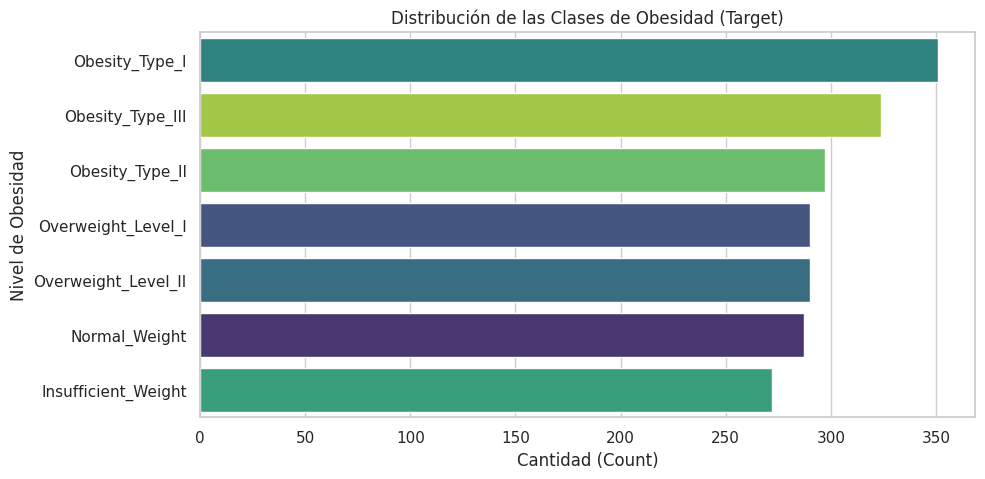

In [93]:
plt.figure(figsize=(10, 5))
sns.countplot(y='nobeyesdad', data=df, 
              order=df['nobeyesdad'].value_counts().index, 
              hue='nobeyesdad', palette='viridis', legend=False) # hue y legend -> para evitar warning deprecated futura en versión de seaborn actual
plt.title('Distribución de las Clases de Obesidad (Target)')
plt.xlabel('Cantidad (Count)')
plt.ylabel('Nivel de Obesidad')
plt.show()

Visualizamos la distribución de las clases de obesidad con un gráfico de barras horizontal. Observamos que cada clase tiene aproximadamente 300 registros, lo que indica que el dataset está perfectamente equilibrado. Esto nos evitará aplicar técnicas de remuestreo sintético (SMOTE) en el modelado.

## Identificación de Valores Atípicos (Cálculo del IQR)

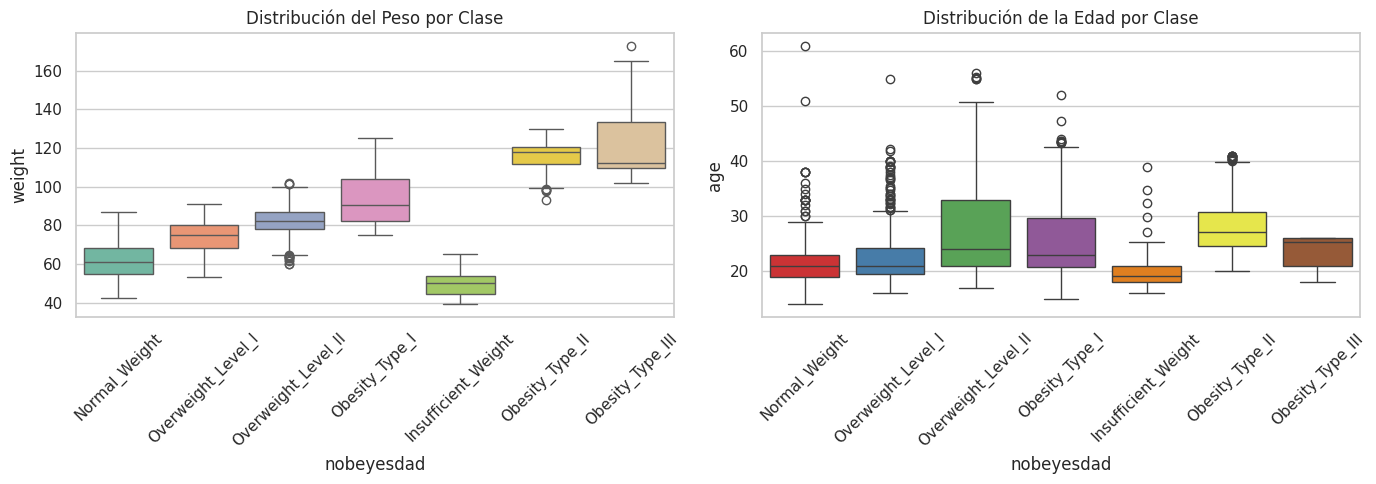

IQR: 6.052807999999999
Límite Superior: 35.079212
Límite Inferior: 10.820788
Pacientes considerados outliers por edad: (168, 17)


In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de Peso
sns.boxplot(ax=axes[0], x='nobeyesdad', y='weight', data=df,
            hue='nobeyesdad', palette='Set2', legend=False) # hue y legend -> lo mismo de antes. Use la variable `hue` para los colores y `legend`para no duplicar información
axes[0].set_title('Distribución del Peso por Clase')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot de Edad
sns.boxplot(ax=axes[1], x='nobeyesdad', y='age', data=df,
            hue='nobeyesdad', palette='Set1', legend=False) # hue y legend
axes[1].set_title('Distribución de la Edad por Clase')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Cálculo del Rango Intercuartílico (IQR) para la Edad
iqr_age = stats.iqr(df["age"])
print(f"IQR: {iqr_age}")

# Límite superior
limite_sup = 26 + (1.5 * iqr_age) # 26 es aprox el Q3
print(f"Límite Superior: {limite_sup}")

# Límite inferior
limite_inf = 19.9 - (1.5 * iqr_age) # 19.9 es aprox el Q1
print(f"Límite Inferior: {limite_inf}")

# Contar pacientes atípicos
pacientes_mayores = df[df["age"] > limite_sup]
print(f"Pacientes considerados outliers por edad: {pacientes_mayores.shape}")


### Conclusiones sobre la Distribución y Outliers (Edad)

- El análisis exploratorio mediante diagramas de caja muestra que tanto el `weight` como la `age` presentan variabilidad entre las distintas categorías de obesidad (nobeyesdad). En particular, el `weight` evidencia una mayor dispersión y presencia de valores extremos en las categorías de mayor obesidad, lo que sugiere una relación directa entre el incremento del `weight` y la clasificación en niveles más altos.

En cuanto a la `age`, la distribución es más homogénea entre categorías, aunque se identifican algunos valores atípicos. Aplicando el método del rango intercuartílico (IQR), se ha determinado de forma matemática que los pacientes con edades superiores a aproximadamente 37 años (dependiendo del punto de corte exacto) pueden considerarse valores estadísticamente atípicos dentro de este contexto sintético.

En conjunto, estos resultados indican que:

- El `weight` es una variable altamente discriminante entre las clases de obesidad.

- La `age` presenta menor variabilidad estructural, aunque incluye outliers relevantes.

La detección de valores atípicos (outliers) permite identificar observaciones que podrían distorsionar el análisis.

Como decisión metodológica, este hallazgo se conservará para fases posteriores, donde se procederá a filtrar el dataset eliminando estos valores extremos, con el objetivo de evitar que influyan negativamente en el rendimiento y la capacidad de generalización del modelo de Machine Learning.

## Impacto del Entorno Familiar

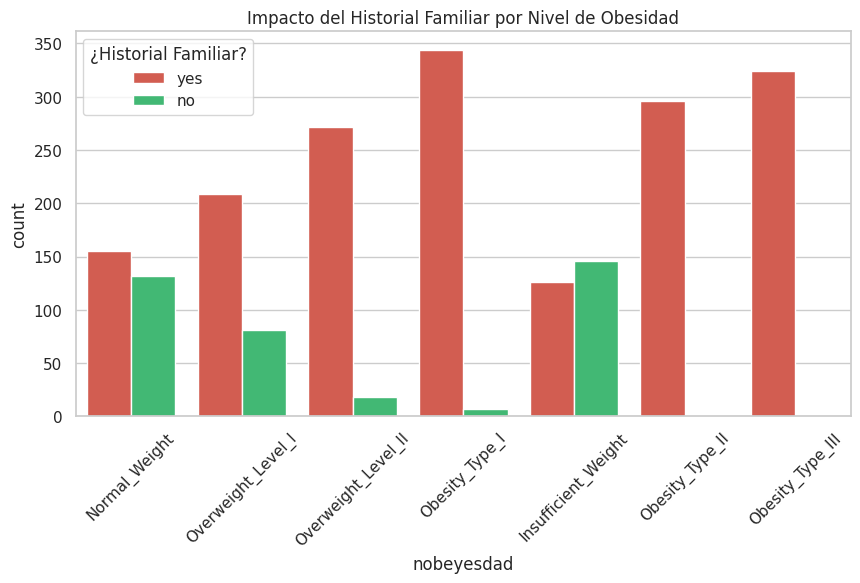

In [95]:
plt.figure(figsize=(10, 5))
sns.countplot(x='nobeyesdad', hue='family_history_with_overweight', data=df,
              palette={'yes': '#e74c3c', 'no': '#2ecc71'}) 
plt.title('Impacto del Historial Familiar por Nivel de Obesidad')
plt.xticks(rotation=45)
plt.legend(title='¿Historial Familiar?')
plt.show()

Analizamos la variable `family_history_with_overweight`  y observamos que en `obesity_type II y III` casi todos los registros tienen historial familiar (casi 100% registros en rojo). Esto indica que es una variable determinante y probablemente será una de nuestras **Top Features** para el modelo. 

### Información en las distintas Categorías y Segmentación

#### Informaciónn en las distintas Categorías


In [96]:
# Extraer columnas de texto
text_columns = df.select_dtypes(include=['object', 'string'])
print(text_columns.columns)

# Iterar para ver las categorías más comunes
for column in text_columns.columns:
    print(f"--- {column.upper()} ---")
    print(df[column].value_counts().head())
    print()

Index(['gender', 'family_history_with_overweight', 'favc', 'caec', 'smoke',
       'scc', 'calc', 'mtrans', 'nobeyesdad'],
      dtype='str')
--- GENDER ---
gender
Male      1068
Female    1043
Name: count, dtype: int64

--- FAMILY_HISTORY_WITH_OVERWEIGHT ---
family_history_with_overweight
yes    1726
no      385
Name: count, dtype: int64

--- FAVC ---
favc
yes    1866
no      245
Name: count, dtype: int64

--- CAEC ---
caec
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

--- SMOKE ---
smoke
no     2067
yes      44
Name: count, dtype: int64

--- SCC ---
scc
no     2015
yes      96
Name: count, dtype: int64

--- CALC ---
calc
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

--- MTRANS ---
mtrans
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64

--- NOBEYE

#### Agrupación de los datos (Segmentación)

In [97]:
# Agrupación por Nivel de Obesidad
df.groupby("nobeyesdad")[["age", "height", "weight"]].agg(["min", "max", "mean"])

# Agrupación por Género y Nivel de Obesidad
df.groupby(["gender", "nobeyesdad"])['age'].agg(["min", "max", "mean"])

# Hábitos de consumo según la Obesidad
df.groupby(['nobeyesdad'])[['fcvc', 'ch2o', 'faf']].mean()



,fcvc,ch2o,faf
nobeyesdad,,,
Insufficient_Weight,2.480788,1.871281,1.250131
Normal_Weight,2.334495,1.850174,1.247387
Obesity_Type_I,2.186050,2.112218,0.986748
Obesity_Type_II,2.391284,1.877658,0.971857
Obesity_Type_III,3.000000,2.208493,0.664817
Overweight_Level_I,2.264631,2.058725,1.056796
Overweight_Level_II,2.260578,2.025133,0.958072


### Conclusiones de la Agrupación y Categorías

- Al agrupar los datos por la variable objetivo (`nobeyesdad`), observamos una **progresión estricta y lógica del peso medio**: a mayor categoría de obesidad, mayor es el peso promedio. No hay cruces ilógicos, lo cual valida la integridad biométrica del dataset.

- En cuanto a los hábitos, notamos que el medio de transporte predominante es el Transporte Público, seguido del coche, lo que suguiere una población de perfil urbano donde el sedentarismo (falta de caminar o ir en bicicleta) puede jugar un rol en el peso.

## Gráficas (Análisis de Relaciones)

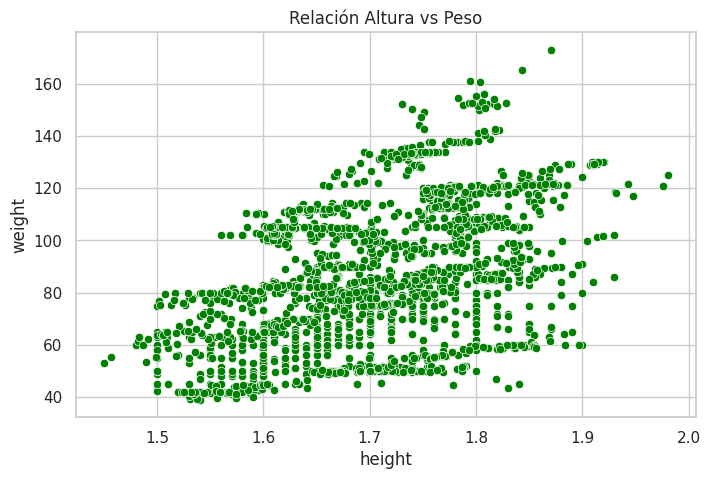

In [98]:
# Relación Altura vs Peso general
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="height", y="weight", color='green')
plt.title("Relación Altura vs Peso")
plt.show()

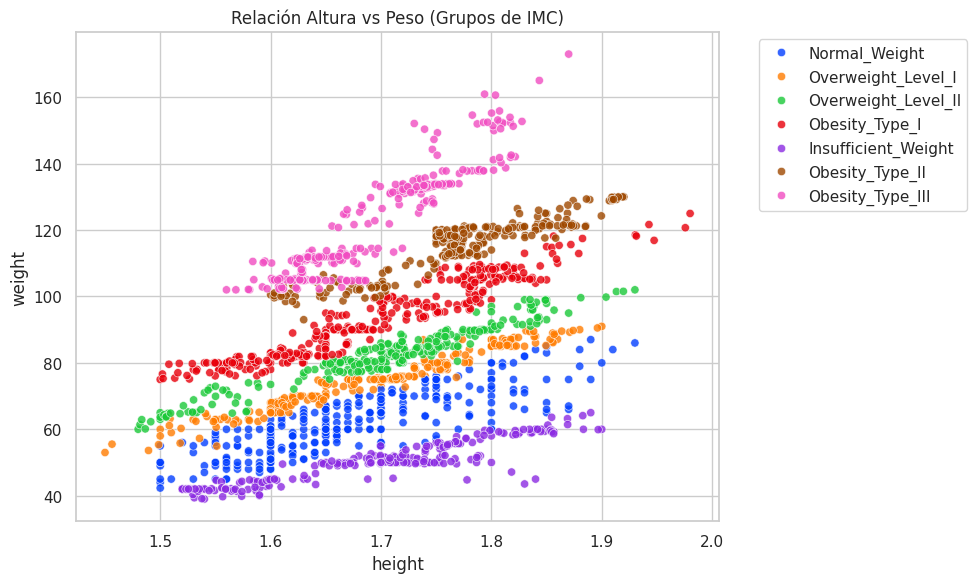

In [99]:
# Relación Altura vs Peso segmentado por Obesidad
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="height", y="weight", hue="nobeyesdad", alpha=0.8, palette="bright")
plt.title("Relación Altura vs Peso (Grupos de IMC)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Conclusiones Relaciones y Segmentado

Visualizamos `height` vs `weight`y notamos que los datos, las bandas de colores, siguen la curva del IMC. No existen errores de entrada humanos graves en las métricas de altura y peso (como alguien muy liviano con altura muy alta), lo que confirma que estas variables son confiables. Los outliers principales siguen estando en `age`.

## Matriz de Correlación

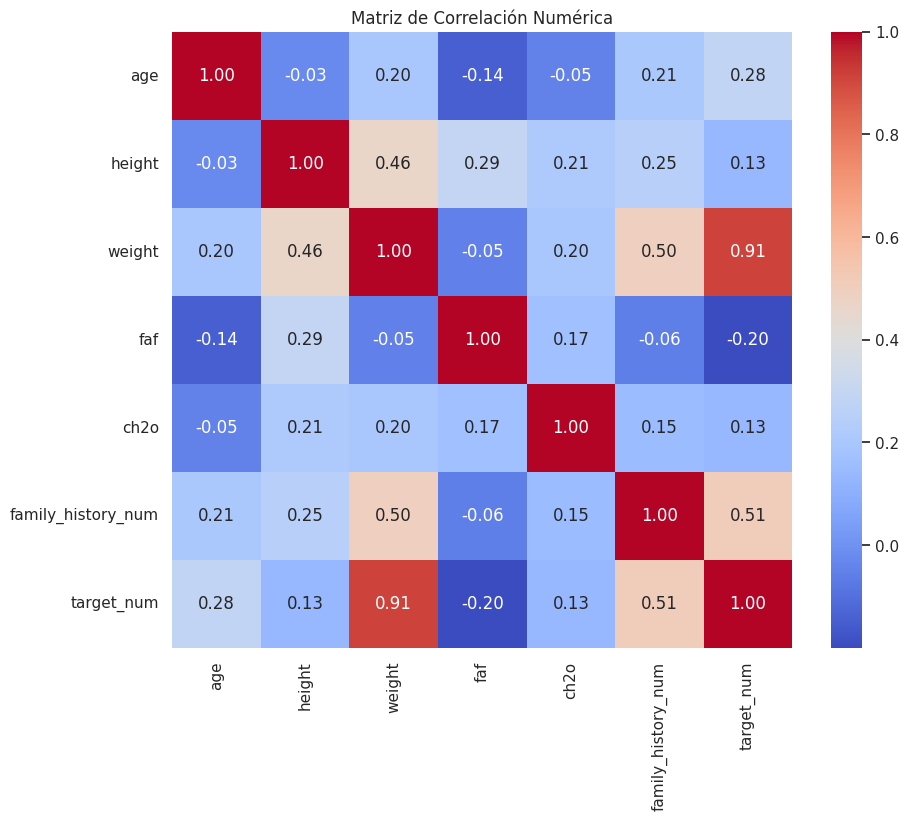

In [100]:
# Mapeo previo para incluir variables clave
data_corr = df.copy()
data_corr['target_num'] = data_corr['nobeyesdad'].map({
    'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2,
    'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6
})
data_corr['family_history_num'] = data_corr['family_history_with_overweight'].map({'yes': 1, 'no': 0})

plt.figure(figsize=(10,8))
sns.heatmap(data_corr[["age", "height", "weight", "faf", "ch2o", "family_history_num", "target_num"]].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación Numérica")
plt.show()

### Conclusiones del Análisis de Relaciones Multivariantes:

1. **Altura vs Peso (Lógica Clínica):** El gráfico de dispersión segmentado por color muestra **franjas** o bandas diagonales casi perfectas. Esto es la representación visual de la fórmula del Índice de Masa Corporal (IMC). Confirma que las clasificaciones médicas en el dataset son matemáticamente correctas y no hay errores de entrada aleatorios. 

2. **Matriz de Correlación (Factores Clave):** 
- **`weight)` (Peso):** Correlación casi perfecta (0.91) con la obesidad, como es de esperar.
- **`family_history_num` (Genética):** Correlación alta y positiva (0.51). Es un desencadenante principal.
- **`faf`(Actividad Física):** Correlación negativa (-0.20). Actúa como factor protector; a mayor actividad, menor grado de obesidad. 
- **`ch2o`(Consumo de Agua):** Leve correlación positiva (0.14. Médicamente se explica porque los cuerpos de mayor volumen requieren de una mayor ingesta absoluta de líquidos).

#### Distribución de Edad según Género

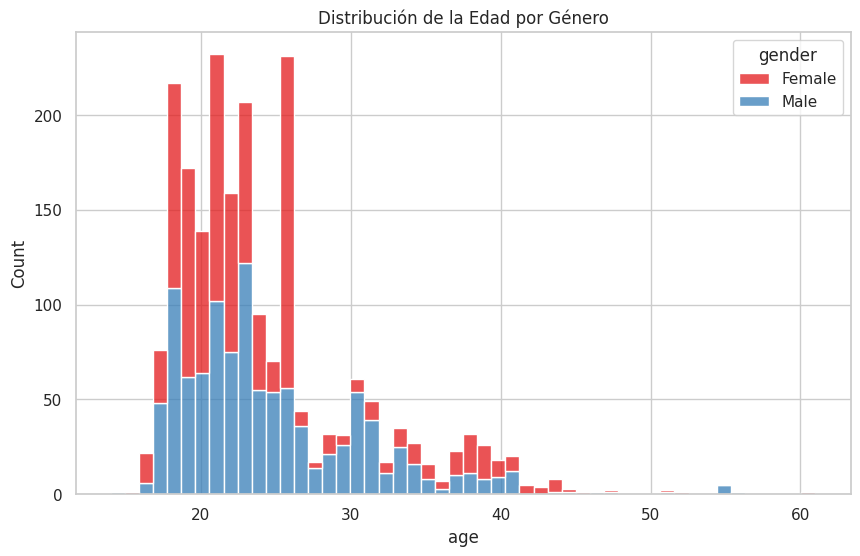

In [101]:
# Distribución de Edad según Género (Uso de hue recomendado)
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="age", hue="gender", bins=50, multiple="stack", palette="Set1")
plt.title("Distribución de la Edad por Género")
plt.show()

#### Histograma por cada género

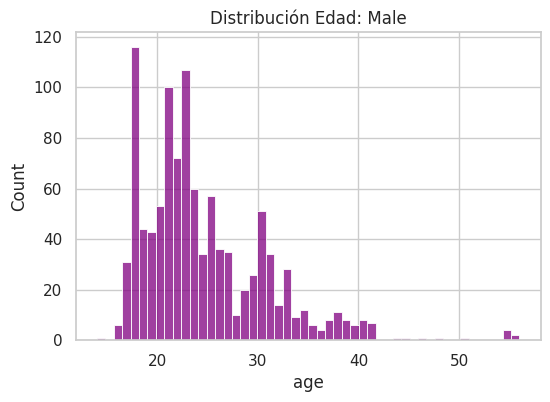

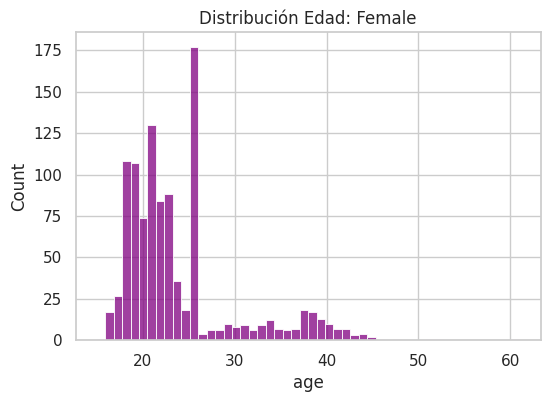

In [102]:
# Histograma por cada género
for value in df["gender"].value_counts().index:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df[df["gender"] == value], x="age", bins=50, color='purple')
    plt.title(f"Distribución Edad: {value}")
    plt.show()

#### Boxplot Edad vs Género

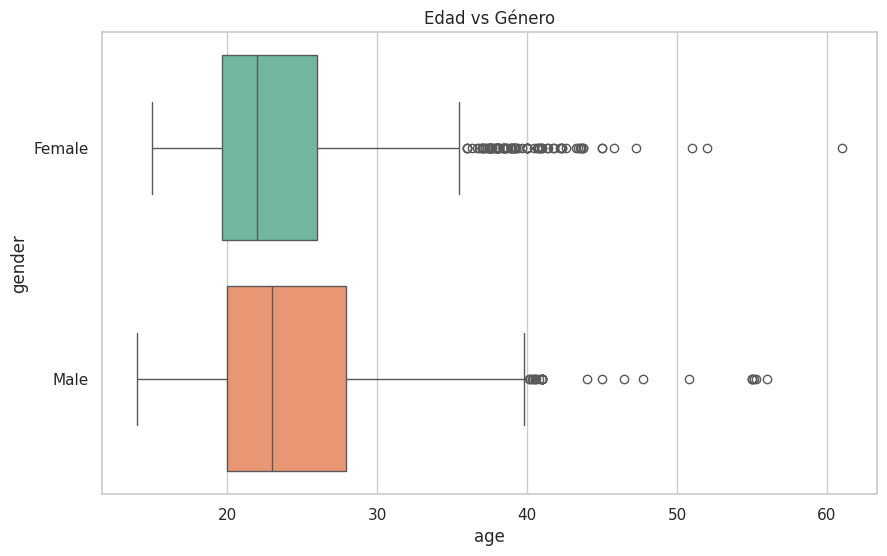

In [103]:
# Boxplot Edad vs Género (Evitando el FutureWarning con hue y legend=False)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="age", y="gender", hue="gender", palette="Set2", legend=False)
plt.title("Edad vs Género")
plt.show()

#### Boxplot Edad vs Género segmentado por Historial Familiar

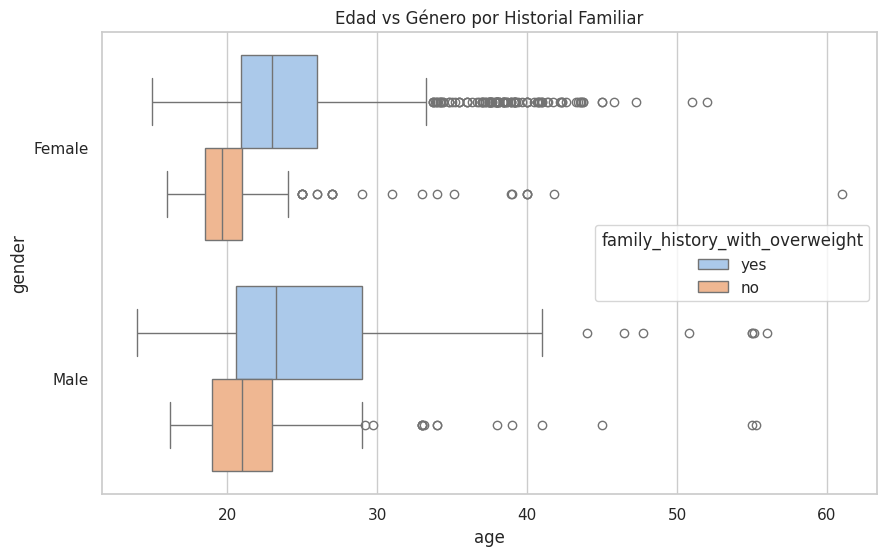

In [104]:
# Boxplot Edad vs Género segmentado por Historial Familiar
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="age", y="gender", hue="family_history_with_overweight", palette="pastel")
plt.title("Edad vs Género por Historial Familiar")
plt.show()



### Gráfico de Pastel (Pie Chart) - Distribución del Target

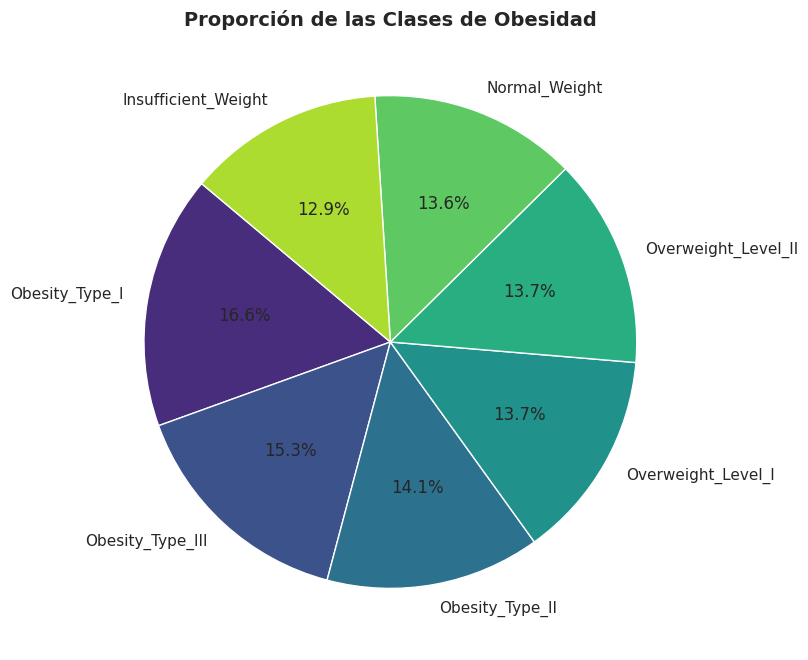

In [105]:
# Gráfico de pastel para la variable Target
plt.figure(figsize=(8, 8))
colores_pie = sns.color_palette("viridis", len(df['nobeyesdad'].unique()))

# Conteo de valores
conteo_clases = df['nobeyesdad'].value_counts()

plt.pie(conteo_clases, 
        labels=conteo_clases.index, 
        autopct='%1.1f%%', 
        colors=colores_pie, 
        startangle=140,
        wedgeprops={'edgecolor': 'white'})

plt.title('Proporción de las Clases de Obesidad', fontweight='bold', fontsize=14)
plt.show()

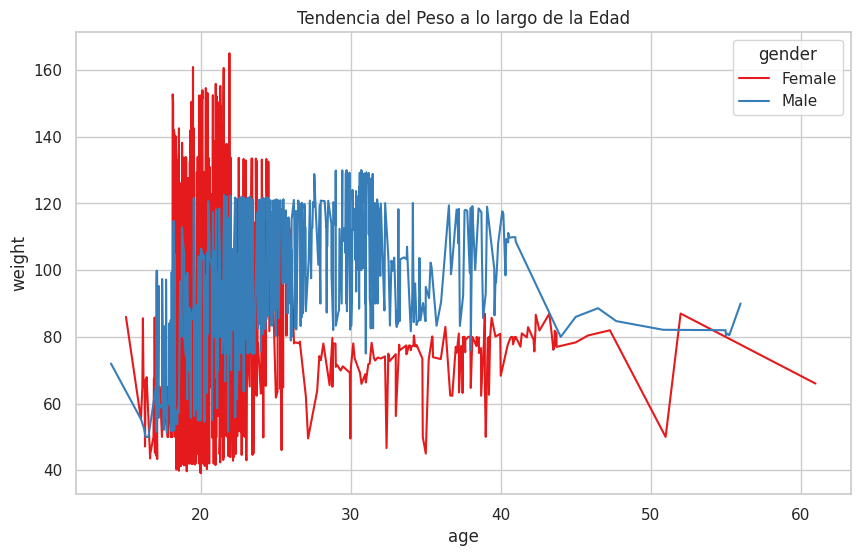

In [106]:
# Lineplot: Evolución del Peso según la Edad (Segmentado por Género)
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="age", y="weight", hue="gender", palette="Set1", errorbar=None)
plt.title("Tendencia del Peso a lo largo de la Edad")
plt.show()

### Conclusiones de Proporción y Tendencias

- **Balanceo Perfecto (Pie Chart):** El gráfico de pastel demuestra que las 7 clases de obesidad representan exactamente entre el 13.5% y el 16.5% del dataset cada una. En Machine Learning, esto es el escenario soñado. Nos garantiza que algoritmos como Random Forest o XGBoost no desarrollarán ssesgos hacia una clase mayoritaria.

- **Edad vs Peso (Lineplot):** Observamos que la tendencia del peso es ascendente durante la juventud y se estabiliza con alta variabilizad (zonas de sombra) pasada la barrera de los 35-40 anños, reafirmando por qué detectamos esos puntos como *outliers* previamente.

## Tratamiento de Datos y Guardado

In [107]:
# Exportación (Documentación y Comunicación)

# Decisión de Negocio y Data Science: 
# Hemos decidido CONSERVAR los valores atípicos (outliers) de la edad.
# Razón: Representan casos clínicos reales de la población adulta y los modelos 
# basados en árboles (Random Forest, XGBoost) son robustos ante ellos.
df_limpio = df.copy()

# Guardar el dataset intacto y estandarizado para el modelo
df_limpio.to_csv('../data/processed/ObesityDataSet_limpio_m.csv', index=False)

print(f"Dimensiones del dataset final (conservando outliers): {df_limpio.shape}")
print("El dataset está listo para la fase de Preprocesamiento y Modelado.")

Dimensiones del dataset final (conservando outliers): (2111, 17)
El dataset está listo para la fase de Preprocesamiento y Modelado.


### Conclusiones sobre la Distribución y Outliers (Edad):
* **Distribución:** La edad está fuertemente sesgada a la derecha (Right-Skewed). La inmensa mayoría de los pacientes tienen entre 18 y 26 años.
* **Valores Atípicos (Outliers):** Utilizando el método del Rango Intercuartílico (IQR), hemos detectado matemáticamente pacientes que superan el límite superior (aprox. 36-37 años). Sin embargo, como decisión de equipo, **hemos optado por no eliminarlos**. Clínicamente, una persona de 45 o 55 años con obesidad es un dato real y valioso. Además, los algoritmos que utilizaremos en la siguiente fase (XGBoost y Random Forest) son inmunes a las distorsiones por valores atípicos.